# FakeAd — detekcija lažnih oglasa za posao

**Problem.** Oglasnici za posao su čest kanal za prevare: lažni oglasi služe za krađu ličnih podataka,
naplatu "kotizacije" za obuku ili regrutovanje za pranje novca. Cilj ovog rada je automatska detekcija
takvih oglasa na osnovu samog teksta oglasa.

**Podaci.** *Employment Scam Aegean Dataset (EMSCAD)* — 17.880 realnih oglasa za posao, od kojih je
866 (4,84%) označeno kao lažno. Skup je izrazito **nebalansiran**, što diktira i izbor modela i izbor metrika.

**Arhitektura rešenja (tri sloja).**

| Sloj | Model | Uloga |
|---|---|---|
| 1. Baseline | TF-IDF + logistička regresija | referentna tačka, potpuno interpretabilan |
| 2. Glavni model | DistilBERT (fine-tuning) | razumevanje konteksta, veća preciznost |
| 3. Objašnjenje | LLM (Groq, `gpt-oss-20b`) | prevodi predikciju u "crvene signale" razumljive korisniku |

**Metrike.** Zbog nebalansiranosti, *accuracy* je neinformativan (model koji sve proglasi ispravnim ima 95%).
Zato pratimo **precision / recall / F1 za klasu "lažno"** i **PR-AUC**, koji je za retku pozitivnu klasu
informativniji od ROC-AUC.

**Okruženje.** Notebook je pisan za Google Colab sa GPU runtime-om (T4). Rezultat treniranja se izvozi i
koristi u lokalnoj Streamlit aplikaciji (`inteligentni sistemi/app.py`).

---

## 1. Učitavanje podataka

### 1.1 Upload dataset-a u Colab

Colab sesija je privremena, pa se `DataSet.csv` (EMSCAD) učitava ručno na početku svake sesije.
Alternativa bi bila montiranje Google Drive-a ili preuzimanje preko Kaggle API-ja.

In [1]:
from google.colab import files
uploaded = files.upload()   # izaberi DataSet.csv

Saving DataSet.csv to DataSet.csv


### 1.2 Prvi pregled i raspodela klasa

Ciljna promenljiva `fraudulent` je u izvornom fajlu tekstualna (`t`/`f`), pa je mapiramo u binarnu (1/0)
da bi bila upotrebljiva u scikit-learn-u.

Ovde prvi put vidimo ključnu karakteristiku problema — **nebalansiranost klasa** (~4,8% lažnih oglasa).
Ta činjenica utiče na sve kasnije odluke: `stratify` pri deljenju podataka, `class_weight="balanced"`
kod logističke regresije, težine u loss funkciji kod DistilBERT-a i izbor PR-AUC kao glavne metrike.

In [2]:
import pandas as pd

df = pd.read_csv("DataSet.csv")

# Labela je 't'/'f' -> pretvaramo u 1/0
df["fraudulent"] = df["fraudulent"].map({"t": 1, "f": 0})

print("Oblik:", df.shape)
print("\nRaspodela klasa (0=pravi, 1=lažni):")
print(df["fraudulent"].value_counts())
print("\nProcenat lažnih:", round(df["fraudulent"].mean() * 100, 2), "%")

df.head(3)

Oblik: (17880, 18)

Raspodela klasa (0=pravi, 1=lažni):
fraudulent
0    17014
1      866
Name: count, dtype: int64

Procenat lažnih: 4.84 %


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,0,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,0,f


## 2. Priprema teksta i eksplorativna analiza (EDA)

Tekst oglasa dolazi iz pet odvojenih kolona i sadrži HTML markup (`<p>`, `<br>`, `&amp;`...), koji je
šum za model. Zato:

1. **spajamo** `title`, `company_profile`, `description`, `requirements` i `benefits` u jedno polje `text`
   (nedostajuće vrednosti tretiramo kao prazan string — odsustvo opisa je i samo po sebi signal),
2. **čistimo** HTML tagove i višestruke razmake regularnim izrazima.

Zatim gledamo tri stvari:
- **dužinu teksta po klasi** — lažni oglasi su u proseku kraći (2.081 vs 2.703 karaktera), što sugeriše da
  prevaranti ulažu manje truda u opis;
- **procenat nedostajućih vrednosti** — npr. `company_profile` nedostaje u 18,5% slučajeva, a odsustvo
  profila kompanije je poznat indikator prevare;
- **konkretan primer lažnog oglasa**, radi kvalitativnog uvida u to kako takvi oglasi izgledaju.

In [3]:
import re

# Skidamo HTML tagove i višak razmaka
def clean_html(x):
    x = re.sub(r"<[^>]+>", " ", str(x))   # ukloni <tagove>
    x = re.sub(r"\s+", " ", x)            # sažmi razmake
    return x.strip()

text_cols = ["title", "company_profile", "description", "requirements", "benefits"]
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1).apply(clean_html)

# Dužina teksta po klasi — često se lažni i pravi razlikuju već po dužini
df["text_len"] = df["text"].str.len()
print("Prosečna dužina teksta po klasi:")
print(df.groupby("fraudulent")["text_len"].mean().round(0))

# Nedostajuće vrednosti
print("\nNedostajuće (%):")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

# Pogledaj jedan lažan oglas
print("\n--- Primer LAŽNOG oglasa ---")
print(df[df["fraudulent"] == 1]["text"].iloc[0][:800])

Prosečna dužina teksta po klasi:
fraudulent
0    2703.0
1    2081.0
Name: text_len, dtype: float64

Nedostajuće (%):
salary_range           84.0
department             64.6
required_education     45.3
benefits               40.2
required_experience    39.4
function               36.1
industry               27.4
employment_type        19.4
company_profile        18.5
requirements           15.0
location                1.9
title                   0.0
has_questions           0.0
has_company_logo        0.0
telecommuting           0.0
description             0.0
fraudulent              0.0
in_balanced_dataset     0.0
text                    0.0
text_len                0.0
dtype: float64

--- Primer LAŽNOG oglasa ---
IC&E Technician Staffing &amp; Recruiting done right for the Oil &amp; Energy Industry! Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant 

### 2.1 Vizuelizacija — raspodela dužine teksta po klasi

Brojevi iz prethodne ćelije (prosek 2.081 vs 2.703 karaktera) kriju oblik raspodele. Histogram pokazuje da
razlika nije samo u proseku: raspodela lažnih oglasa je pomerena ulevo i ima izraženiji vrh na malim
dužinama, dok pravi oglasi imaju duži desni rep.

Zbog nebalansiranosti klasa histogram je **normalizovan po gustini** — inače bi stubić klase "pravi"
(17.014 primera) potpuno progutao klasu "lažni" (866 primera). Isprekidane linije označavaju medijane.

Ovde se ujedno postavlja paleta boja koja se dosledno koristi u svim grafikonima u radu.

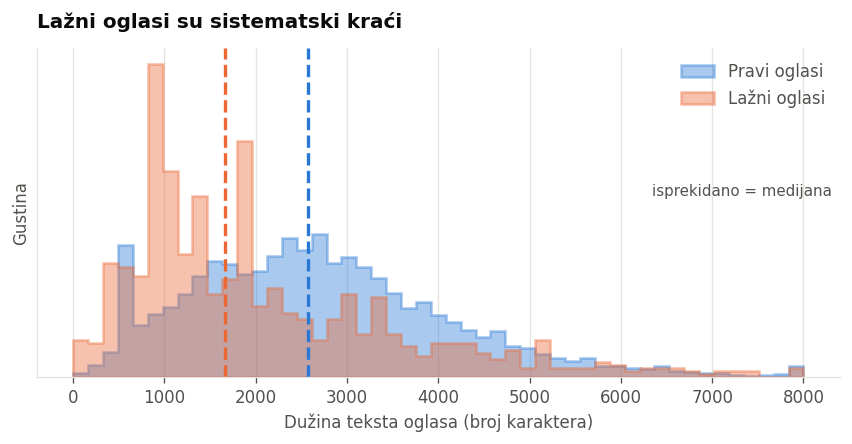

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Paleta i stil (koristi se u svim grafikonima ispod) ----------
PLAVA, NARANDZ = "#2a78d6", "#eb6834"
INK, INK2, MREZA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": MREZA, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.axisbelow": True,
    "grid.color": MREZA, "grid.linewidth": 0.8,
})

def _ocisti(ax):
    """Uklanja gornju i desnu ivicu — manje 'mastila', fokus na podacima."""
    for strana in ("top", "right"):
        ax.spines[strana].set_visible(False)

# ---------- Histogram dužine teksta po klasi ----------
GRANICA = 8000                      # rep raspodele se odseca radi čitljivosti
korpe = np.linspace(0, GRANICA, 50)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for maska, boja, ime in [(df["fraudulent"] == 0, PLAVA, "Pravi oglasi"),
                         (df["fraudulent"] == 1, NARANDZ, "Lažni oglasi")]:
    duzine = df.loc[maska, "text_len"].clip(upper=GRANICA)
    ax.hist(duzine, bins=korpe, density=True, histtype="stepfilled", alpha=0.4,
            facecolor=boja, edgecolor=boja, linewidth=1.6, label=ime)
    ax.axvline(duzine.median(), color=boja, linewidth=2, linestyle="--")

ax.set_title("Lažni oglasi su sistematski kraći", loc="left",
             color=INK, fontweight="bold", pad=12)
ax.set_xlabel("Dužina teksta oglasa (broj karaktera)")
ax.set_ylabel("Gustina")
ax.set_yticks([])                   # apsolutne vrednosti gustine nisu informativne
ax.grid(axis="x")
ax.legend(frameon=False, labelcolor=INK2)
ax.text(0.99, 0.55, "isprekidano = medijana", transform=ax.transAxes,
        ha="right", color=INK2, fontsize=9)
_ocisti(ax)
plt.tight_layout()
plt.show()

## 3. Baseline model — TF-IDF + logistička regresija

Pre nego što se posegne za neuronskim mrežama, potrebna je **referentna tačka**: jednostavan model koji
pokazuje koliko se problema može rešiti klasičnim pristupom. Bez njega ne znamo da li kompleksniji model
uopšte donosi korist.

Ključne odluke i njihovo obrazloženje:

- `train_test_split(..., stratify=y, random_state=42)` — stratifikacija čuva isti odnos klasa u train i test
  skupu (bez nje bi test skup sa 4,8% pozitivnih primera bio nestabilan); fiksiran `random_state`
  obezbeđuje **reproducibilnost** i, što je važnije, **isti test skup** za oba modela.
- `TfidfVectorizer(ngram_range=(1,2))` — bigrami hvataju fraze poput *"work home"* ili *"data entry"*,
  koje unigrami razbijaju i gube značenje.
- `min_df=5` i `max_features=20000` — uklanjaju retke reči (uglavnom tipografske greške i imena) i
  ograničavaju dimenzionalnost, čime se smanjuje overfitting.
- `class_weight="balanced"` — greške na retkoj klasi se kažnjavaju jače, srazmerno inverznoj frekvenciji klase.

Rezultat se prikazuje kroz izveštaj klasifikacije, matricu konfuzije i PR-AUC/ROC-AUC.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score)

X = df["text"]
y = df["fraudulent"]

# stratify=y -> čuva isti odnos klasa u train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: pretvara tekst u brojeve. unigrami+bigrami, izbacujemo retke reči (min_df=5)
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                             stop_words="english", min_df=5)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# class_weight="balanced" -> model kažnjava greške na retkoj klasi jače (rešava imbalans)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_tfidf, y_train)

y_pred  = clf.predict(X_test_tfidf)
y_proba = clf.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("Matrica konfuzije  [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test, y_pred))
print("\nPR-AUC (average precision):", round(average_precision_score(y_test, y_proba), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

              precision    recall  f1-score   support

           0      0.995     0.986     0.991      3403
           1      0.766     0.908     0.831       173

    accuracy                          0.982      3576
   macro avg      0.881     0.947     0.911      3576
weighted avg      0.984     0.982     0.983      3576

Matrica konfuzije  [[TN FP] [FN TP]]:
[[3355   48]
 [  16  157]]

PR-AUC (average precision): 0.921
ROC-AUC: 0.988


### 3.1 Interpretacija baseline modela

Prednost linearnog modela je što su njegovi koeficijenti direktno čitljivi: pozitivan koeficijent gura
predikciju ka klasi "lažno", negativan ka "pravo". Ispisujemo po 25 najuticajnijih reči u oba smera.

Ovaj korak je i **provera zdravog razuma**: ako se među najjačim signalima nađu izrazi tipa *"earn"*,
*"money"*, *"data entry"*, *"work home"* — model je naučio semantički smislene obrasce, a ne artefakte
dataset-a. Treba primetiti i da neki tokeni (npr. imena konkretnih kompanija) upućuju na to da model
delimično pamti specifične izvore oglasa, što je ograničenje ovakvog pristupa.

In [6]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

top_fake = np.argsort(coefs)[-25:][::-1]      # najveći pozitivni -> ka "lažno"
top_real = np.argsort(coefs)[:25]             # najveći negativni -> ka "pravo"

print("🚩 Reči koje najviše ukazuju na LAŽAN oglas:")
for i in top_fake:
    print(f"   {feature_names[i]:30s} {coefs[i]:+.2f}")

print("\n✅ Reči koje najviše ukazuju na PRAVI oglas:")
for i in top_real:
    print(f"   {feature_names[i]:30s} {coefs[i]:+.2f}")

🚩 Reči koje najviše ukazuju na LAŽAN oglas:
   link                           +4.03
   accion                         +3.64
   earn                           +3.43
   data entry                     +3.43
   money                          +3.11
   clerk                          +2.90
   subsea                         +2.88
   assistant                      +2.87
   cash                           +2.86
   hospital                       +2.84
   novation                       +2.83
   aecom                          +2.77
   surgical                       +2.68
   aptitude staffing              +2.67
   receptionist                   +2.62
   work home                      +2.60
   offshore                       +2.54
   entry                          +2.51
   accountant                     +2.40
   administrative assistant       +2.40
   000                            +2.37
   requirements                   +2.37
   aptitude                       +2.36
   engineering                    +2

## 4. Glavni model — fine-tuning DistilBERT-a

TF-IDF posmatra dokument kao "vreću reči" i ne razume kontekst ni redosled. Transformer model koristi
kontekstualne reprezentacije, pa razlikuje npr. legitimno pominjanje plate od nerealnog obećanja zarade.

Biramo **DistilBERT** — destilovanu verziju BERT-a sa ~40% manje parametara i ~60% bržim izvršavanjem uz
zadržanih ~97% performansi. To ga čini realno upotrebljivim na besplatnom Colab GPU-u i u aplikaciji koja
treba da odgovori u realnom vremenu.

### 4.1 Instalacija biblioteka

In [7]:
# Colab vec ima pandas/torch/sklearn. NE diramo pyarrow: njegov upgrade nad
# pokrenutim kernelom ruši `datasets` ("IpcReadOptions size changed").
!pip install -q -U "transformers>=4.40" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 83.8 MB/s eta 0:00:00


### 4.2 Tokenizacija i priprema podataka

Podelu podataka ponavljamo sa **istim `random_state` i istim `stratify`** kao u baseline-u — tako oba
modela vide identičan test skup i poređenje je metodološki korektno.

Tekst se tokenizuje DistilBERT tokenizatorom (WordPiece) i pakuje u jednostavan `torch.utils.data.Dataset`.

> **Zašto ne `datasets.Dataset`?** Ta biblioteka zavisi od `pyarrow`, a njegova nadogradnja u već pokrenutom
> Colab kernelu izaziva grešku `ValueError: pyarrow.lib.IpcReadOptions size changed`. Pošto HuggingFace
> `Trainer` podjednako dobro radi sa običnim PyTorch Dataset-om, cela ta zavisnost je izbačena.

`max_length=256` je kompromis: oglasi su često duži od toga, ali vreme treniranja raste sa dužinom sekvence.
`DataCollatorWithPadding` radi **dinamički padding** — dopunjava do najduže sekvence u batch-u umesto do
fiksne dužine, čime se izbegava nepotrebno računanje nad padding tokenima.

In [8]:
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# Isti random_state i stratify kao u baseline-u -> isti test skup -> pošteno poređenje
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["fraudulent"], test_size=0.2, random_state=42, stratify=df["fraudulent"]
)

class OglasiDataset(torch.utils.data.Dataset):
    """Minimalan PyTorch Dataset nad tokenizovanim oglasima.

    Namerno se NE koristi `datasets.Dataset`: ta biblioteka vuče pyarrow, čiji
    upgrade u već pokrenutom Colab kernelu izaziva grešku binarne nekompatibilnosti.
    Trainer podjednako dobro radi sa običnim torch Dataset-om.
    """
    def __init__(self, tekstovi, labele, tokenizer, max_length=256):
        # max_length=256 zbog brzine (oglasi su dugi; 512 hvata više ali je sporije)
        self.kodovi = tokenizer(list(tekstovi), truncation=True, max_length=max_length)
        self.labele = [int(v) for v in labele]

    def __len__(self):
        return len(self.labele)

    def __getitem__(self, i):
        stavka = {k: v[i] for k, v in self.kodovi.items()}
        stavka["labels"] = self.labele[i]
        return stavka

train_ds = OglasiDataset(X_train, y_train, tokenizer)
test_ds  = OglasiDataset(X_test,  y_test,  tokenizer)

# Dinamički padding: dopunjava do najduže sekvence u batch-u, ne do fiksnih 256
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Spremno. Train:", len(train_ds), "Test:", len(test_ds))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Spremno. Train: 14304 Test: 3576


### 4.3 Treniranje sa težinama klasa

Standardni `Trainer` koristi običnu cross-entropy funkciju gubitka, koja bi kod odnosa 95:5 favorizovala
većinsku klasu. Zato nasleđujemo `Trainer` i prepisujemo `compute_loss` tako da koristi
`CrossEntropyLoss(weight=...)` sa težinama izračunatim po formuli `N / (2 * n_klase)` — greška na lažnom
oglasu tako "boli" oko 20 puta više nego greška na pravom.

Ovo je opravdano i iz domenskog ugla: propušten lažni oglas (false negative) šteti korisniku mnogo više nego
lažna uzbuna (false positive), koja se rešava jednim ljudskim pregledom.

`compute_metrics` prati metrike specifično za klasu "lažno" plus PR-AUC, a ne globalnu tačnost.

Hiperparametri (`lr=2e-5`, 3 epohe, batch 16) su standardne preporučene vrednosti za fine-tuning BERT
familije; više epoha na ovako malom skupu vodi ka overfitting-u.

In [9]:
import torch
import numpy as np
import torch.nn as nn
from scipy.special import softmax
from sklearn.metrics import precision_recall_fscore_support, average_precision_score
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)

# Težine klasa -> model jače kažnjava greške na retkoj "lažno" klasi
n0, n1 = (y_train == 0).sum(), (y_train == 1).sum()
N = len(y_train)
class_weights = torch.tensor([N/(2*n0), N/(2*n1)], dtype=torch.float)
print("Težine klasa [pravo, lažno]:", class_weights.tolist())

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits, axis=1)[:, 1]
    preds = logits.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average=None, labels=[0, 1])
    return {"precision_fake": p[1], "recall_fake": r[1], "f1_fake": f1[1],
            "pr_auc": average_precision_score(labels, probs)}

args = TrainingArguments(
    output_dir="out", num_train_epochs=3,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, eval_strategy="epoch", logging_steps=50, report_to="none",
)

trainer = WeightedTrainer(
    model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds,
    data_collator=collator, compute_metrics=compute_metrics,
)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Težine klasa [pravo, lažno]: [0.5254573225975037, 10.320345878601074]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2682, training_loss=0.25016809263218703, metrics={'train_runtime': 1243.9194, 'train_samples_per_second': 34.497, 'train_steps_per_second': 2.156, 'total_flos': 2842220505563136.0, 'train_loss': 0.25016809263218703, 'epoch': 3.0})

### 4.4 Evaluacija i poređenje sa baseline-om

| Model | Precision (lažno) | Recall (lažno) | PR-AUC |
|---|---|---|---|
| TF-IDF + Log. regresija | 0,766 | 0,908 | 0,921 |
| DistilBERT | 0,924 | 0,844 | 0,934 |

Interpretacija: DistilBERT drastično smanjuje broj lažnih uzbuna (48 → 12 false positives), uz nešto niži
recall (157 → 146 otkrivenih lažnih oglasa). PR-AUC je blago u njegovu korist (0,921 → 0,934), što znači da
su modeli bliski "u proseku po svim pragovima", ali DistilBERT nudi bolji radni kompromis na pragu 0,5.

Zaključak nije trivijalan: **složeniji model nije apsolutno bolji, već pomera kompromis**. Ako je prioritet
da se ne propusti nijedna prevara, baseline sa višim recall-om je konkurentan; ako je prioritet poverenje
korisnika u sistem, DistilBERT je bolji izbor.

> **Napomena o reproducibilnosti.** Baseline vrednosti u poređenju ispod su upisane ručno, iz prethodnog
> izvršavanja ćelije sa baseline modelom. Uz to, `TrainingArguments` nema fiksiran `seed`, pa svako ponovno
> treniranje daje blago drugačije rezultate (u jednom ranijem pokretanju: precision 0,937 / recall 0,855 /
> PR-AUC 0,926). Zaključci se ne menjaju, ali za potpuno reproducibilan rad treba dodati `seed=42` u
> `TrainingArguments`.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(-1)

print(classification_report(y_test, y_pred, digits=3))
print("Matrica konfuzije [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test, y_pred))
print("\n--- Poređenje na klasi 'lažno' ---")
print("Baseline (TF-IDF):  precision 0.766 | recall 0.908 | PR-AUC 0.921")
print(f"DistilBERT:         precision {pred.metrics['test_precision_fake']:.3f} | "
      f"recall {pred.metrics['test_recall_fake']:.3f} | PR-AUC {pred.metrics['test_pr_auc']:.3f}")

              precision    recall  f1-score   support

           0      0.992     0.996     0.994      3403
           1      0.924     0.844     0.882       173

    accuracy                          0.989      3576
   macro avg      0.958     0.920     0.938      3576
weighted avg      0.989     0.989     0.989      3576

Matrica konfuzije [[TN FP] [FN TP]]:
[[3391   12]
 [  27  146]]

--- Poređenje na klasi 'lažno' ---
Baseline (TF-IDF):  precision 0.766 | recall 0.908 | PR-AUC 0.921
DistilBERT:         precision 0.924 | recall 0.844 | PR-AUC 0.934


### 4.5 Vizuelizacija poređenja — PR krive i matrice konfuzije

Tabela iznad poredi modele **na jednom pragu** (0,5). PR kriva pokazuje ponašanje **na svim pragovima
odjednom** i zato je informativnija: svaka tačka na krivoj je jedan mogući radni režim sistema.

Isprekidana horizontalna linija je nivo slučajnog modela — jednak udelu pozitivne klase (0,048). Oba modela
su daleko iznad nje, što potvrđuje da signal u tekstu postoji.

Matrice konfuzije su **normalizovane po redovima** (svaki red = 100% stvarne klase), jer bi u apsolutnim
brojevima polje sa 3.393 tačno klasifikovana prava oglasa vizuelno potisnulo sve ostalo. U svakom polju je
ispisan i apsolutni broj i procenat unutar reda.

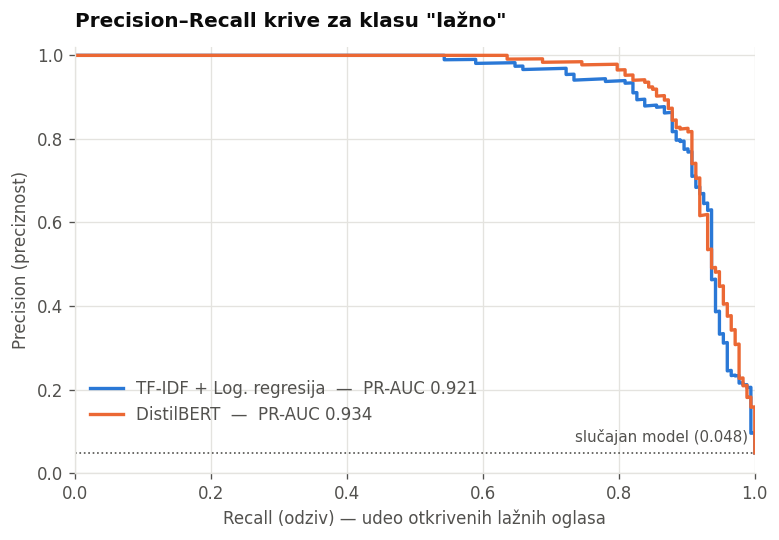

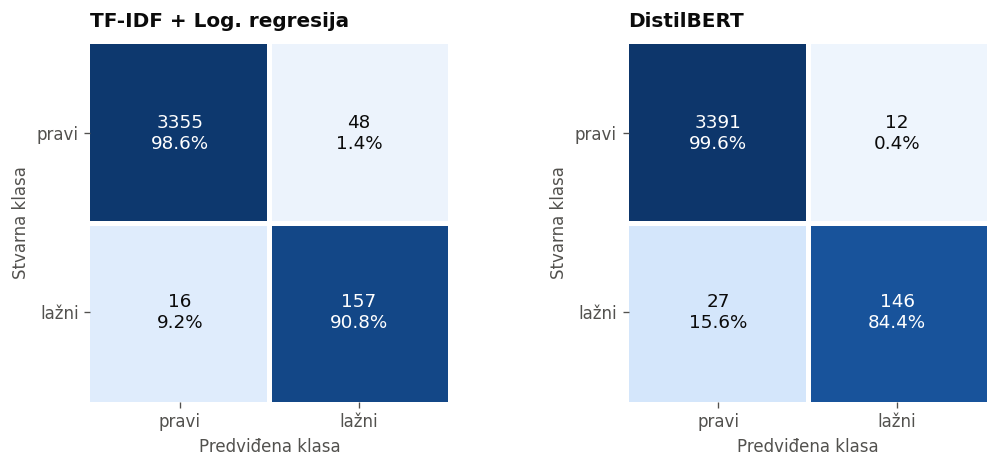

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
from scipy.special import softmax
from matplotlib.colors import LinearSegmentedColormap

PLAVA, NARANDZ = "#2a78d6", "#eb6834"
INK, INK2 = "#0b0b0b", "#52514e"

# Verovatnoće klase "lažno" za oba modela nad ISTIM test skupom
p_baseline = y_proba                                  # iz ćelije sa baseline modelom
p_bert     = softmax(pred.predictions, axis=1)[:, 1]  # iz predikcije DistilBERT-a

modeli = [("TF-IDF + Log. regresija", p_baseline, PLAVA),
          ("DistilBERT",              p_bert,     NARANDZ)]

# ---------- 1) PR krive oba modela na istom grafiku ----------
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for ime, p, boja in modeli:
    preciznost, odziv, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    ax.plot(odziv, preciznost, linewidth=2, color=boja, label=f"{ime}  —  PR-AUC {ap:.3f}")

udeo_pozitivnih = y_test.mean()
ax.axhline(udeo_pozitivnih, color=INK2, linewidth=1, linestyle=":")
ax.text(0.99, udeo_pozitivnih + 0.02, f"slučajan model ({udeo_pozitivnih:.3f})",
        ha="right", va="bottom", color=INK2, fontsize=9)

ax.set_title("Precision–Recall krive za klasu \"lažno\"", loc="left",
             color=INK, fontweight="bold", pad=12)
ax.set_xlabel("Recall (odziv) — udeo otkrivenih lažnih oglasa")
ax.set_ylabel("Precision (preciznost)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.grid(True)
ax.legend(frameon=False, labelcolor=INK2, loc="lower left",
          bbox_to_anchor=(0.0, 0.08))
_ocisti(ax)
plt.tight_layout()
plt.show()

# ---------- 2) Matrice konfuzije, normalizovane po redovima ----------
# Sekvencijalna rampa: jedna boja, svetlo -> tamno. Ne krece od ciste bele,
# da bi i polje sa vrednoscu 0 ostalo vidljivo na beloj pozadini.
rampa = LinearSegmentedColormap.from_list(
    "plava_rampa", ["#eef5fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
oznake = ["pravi", "lažni"]

fig, osa = plt.subplots(1, 2, figsize=(9.2, 4.0))
for ax, (ime, p, _) in zip(osa, modeli):
    mk = confusion_matrix(y_test, (p >= 0.5).astype(int))
    mk_norm = mk / mk.sum(axis=1, keepdims=True)

    ax.imshow(mk_norm, cmap=rampa, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{mk[i, j]}\n{mk_norm[i, j]:.1%}", ha="center", va="center",
                    fontsize=11, color="white" if mk_norm[i, j] > 0.55 else INK)

    ax.set_title(ime, loc="left", color=INK, fontweight="bold", pad=10)
    ax.set_xticks([0, 1], labels=oznake)
    ax.set_yticks([0, 1], labels=oznake)
    ax.set_xlabel("Predviđena klasa"); ax.set_ylabel("Stvarna klasa")
    # Bele razdvojne linije izmedju polja
    ax.set_xticks([0.5], minor=True); ax.set_yticks([0.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    for strana in ax.spines.values():
        strana.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Treći sloj — LLM objašnjenje predikcije

Broj "83% verovatnoće prevare" korisniku ne govori *zašto*. Zato se iznad klasifikatora dodaje LLM sloj koji
tekst oglasa pretvara u konkretne, čitljive **crvene signale**.

Podela odgovornosti je namerna:
- **DistilBERT** daje kvantitativnu ocenu (treniran na 14.304 realna primera, pouzdan i deterministički),
- **LLM** daje kvalitativno obrazloženje (fleksibilan, ali sklon halucinacijama — zato mu se *ne* poverava
  konačna odluka).

Koristi se Groq API (open-source model `gpt-oss-20b`) zbog vrlo male latencije i besplatnog nivoa pristupa.
Ključ se unosi preko `getpass` da ne bi završio u sačuvanom notebook-u — u produkciji bi stajao u
promenljivoj okruženja.

### 5.1 Podešavanje Groq klijenta

In [12]:
!pip install -q groq

from getpass import getpass
import os
os.environ["GROQ_API_KEY"] = getpass("Nalepi svoj Groq API ključ: ")

from groq import Groq
client = Groq(api_key=os.environ["GROQ_API_KEY"])
print("Groq klijent spreman.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.3 MB/s eta 0:00:00
Nalepi svoj Groq API ključ: ··········
Groq klijent spreman.


### 5.2 Funkcija za predikciju DistilBERT-om

Model se prebacuje u `eval()` režim (isključuje dropout) i na GPU ako je dostupan. `torch.no_grad()`
isključuje računanje gradijenata, što ubrzava inferencu i smanjuje potrošnju memorije.

Funkcija vraća `softmax` verovatnoću klase 1 — dakle kontinuiranu ocenu, ne samo binarnu odluku, čime se
prag odlučivanja može podešavati prema potrebi aplikacije.

In [13]:
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

def bert_predict(text):
    """Vrati verovatnoću da je oglas LAŽAN (0-1)."""
    inputs = tokenizer(text, truncation=True, max_length=256, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    prob_fake = F.softmax(logits, dim=1)[0, 1].item()
    return prob_fake

### 5.3 Prompt inženjering za sloj objašnjenja

Prompt je konstruisan tako da smanji prostor za greške modela:

- **system poruka** definiše ulogu i taksonomiju signala koje treba tražiti (nerealna zarada, hitnost,
  traženje uplate ili ličnih podataka, šturi opis, sumnjiv kontakt) — bez toga LLM daje uopštene odgovore;
- **verovatnoća iz DistilBERT-a se prosleđuje** u prompt, pa se objašnjenje usklađuje sa kvantitativnom ocenom;
- `response_format={"type": "json_object"}` i eksplicitno zadata šema izlaza garantuju mašinski čitljiv
  odgovor, koji aplikacija može direktno da parsira;
- `temperature=0.2` — niska temperatura jer nam treba dosledna analiza, a ne kreativnost;
- `text[:3000]` — ograničenje ulaza radi kontrole troška i latencije.

In [14]:
import json

def llm_explain(text, prob_fake):
    """LLM analizira oglas i vraća objašnjenje crvenih signala (na srpskom)."""
    system = (
        "Ti si analitičar za detekciju prevara u oglasima za posao. "
        "Analiziraš tekst oglasa i identifikuješ konkretne 'crvene signale' koji "
        "ukazuju na moguću prevaru (nerealna zarada, hitnost, traženje uplate ili "
        "ličnih podataka, uopšten/šturi opis, sumnjiv kontakt, obećanja bez pokrića). "
        "Odgovaraš ISKLJUČIVO na srpskom jeziku i ISKLJUČIVO validnim JSON objektom, "
        "bez ikakvog teksta pre ili posle."
    )
    user = f"""Model mašinskog učenja je ovom oglasu dao verovatnoću prevare od {prob_fake:.0%}.

Tekst oglasa:
\"\"\"{text[:3000]}\"\"\"

Vrati JSON tačno u ovom formatu:
{{
  "procena": "verovatno lažno" | "sumnjivo" | "verovatno pravo",
  "crveni_signali": ["kratak signal 1", "signal 2", "..."],
  "objasnjenje": "2-3 rečenice zašto, ljudskim jezikom"
}}"""

    resp = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "system", "content": system},
                  {"role": "user", "content": user}],
        temperature=0.2,
        response_format={"type": "json_object"},  # tera model da vrati validan JSON
    )
    return json.loads(resp.choices[0].message.content)

### 5.4 Kompletan pipeline na konkretnom primeru

`analyze_ad` spaja sva tri sloja u jedan poziv i vraća objedinjen rezultat: verovatnoću, procenu, listu
crvenih signala i tekstualno objašnjenje. Isti tok je kasnije implementiran u Streamlit aplikaciji.

In [15]:
def analyze_ad(text):
    prob = bert_predict(text)
    explanation = llm_explain(text, prob)
    return {"verovatnoca_prevare": round(prob, 3), **explanation}

# Uzmi jedan stvarno lažan oglas iz test skupa
primer = df[df["fraudulent"] == 1]["text"].iloc[3]

rezultat = analyze_ad(primer)
print("VEROVATNOĆA PREVARE (DistilBERT):", rezultat["verovatnoca_prevare"])
print("PROCENA (LLM):", rezultat["procena"])
print("\nCRVENI SIGNALI:")
for s in rezultat["crveni_signali"]:
    print("  🚩", s)
print("\nOBJAŠNJENJE:")
print(" ", rezultat["objasnjenje"])

VEROVATNOĆA PREVARE (DistilBERT): 0.667
PROCENA (LLM): sumnjivo

CRVENI SIGNALI:
  🚩 Nedostatak detalja o radnom mestu
  🚩 Nedostatak kontaktnih informacija
  🚩 Ponavljanje iste reči bez dodatnih informacija

OBJAŠNJENJE:
  Oglas sadrži samo ponovljenu frazu bez ikakvih informacija o kompaniji, lokaciji, plati ili kontaktu, što je čest znak prevara. Takav nedostatak detalja i hitnost u komunikaciji ukazuje na potencijalnu prevaru.


## 6. Izvoz modela za aplikaciju

Cilj je da rezultat rada ne ostane u notebook-u, već da se koristi u Streamlit aplikaciji
(`inteligentni sistemi/app.py`), koja radi lokalno bez potrebe za ponovnim treniranjem.

### 6.1 DistilBERT — težine i tokenizator

In [16]:
# Sačuvaj DistilBERT (model + tokenizer)
save_dir = "fakead_model"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

# Spakuj u zip da lakše skineš iz Colab-a
import shutil
shutil.make_archive("fakead_model", "zip", save_dir)
print("Sačuvano u fakead_model/ i fakead_model.zip")

# Skini na računar (za lokalni Streamlit)
from google.colab import files
files.download("fakead_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sačuvano u fakead_model/ i fakead_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 6.2 Baseline — vektorizator i klasifikator

Baseline se ponovo trenira nad istim splitom i serijalizuje pomoću `joblib`. Važno je da se **zajedno**
sačuvaju vektorizator i klasifikator: vektorizator sadrži naučeni rečnik i IDF težine, pa bi model bez njega
dobijao potpuno drugačije ulazne vektore.

Provera veličine fajla je jednostavna kontrola da serijalizacija nije tiho zakazala.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib, os

# Ponovo napravi baseline iz df (isti split kao ranije)
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["fraudulent"], test_size=0.2, random_state=42, stratify=df["fraudulent"]
)
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                             stop_words="english", min_df=5)
Xtr = vectorizer.fit_transform(X_train)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(Xtr, y_train)

# Snimi i PROVERI veličinu
joblib.dump({"vectorizer": vectorizer, "clf": clf}, "baseline.joblib")
size_kb = os.path.getsize("baseline.joblib") / 1024
print(f"Veličina fajla: {size_kb:.1f} KB")   # treba da bude nekoliko stotina KB, NE 0

Veličina fajla: 987.2 KB


### 6.3 Preuzimanje baseline modela

In [18]:
from google.colab import files
files.download("baseline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 7. Zaključak

**Šta je urađeno.** Implementiran je trostepeni sistem za detekciju lažnih oglasa za posao: interpretabilan
baseline (TF-IDF + logistička regresija), fine-tune-ovan DistilBERT i LLM sloj za objašnjenje predikcije.
Modeli su izvezeni i integrisani u Streamlit aplikaciju.

**Rezultati (klasa "lažno", test skup od 3.576 oglasa).**

| Model | Precision | Recall | F1 | PR-AUC |
|---|---|---|---|---|
| TF-IDF + Log. regresija | 0,766 | 0,908 | 0,831 | 0,921 |
| DistilBERT | 0,924 | 0,844 | 0,882 | 0,934 |

**Ograničenja.**
- Dataset je na engleskom jeziku i star nekoliko godina, dok aplikacija odgovara na srpskom — model nije
  validiran na oglasima sa domaćeg tržišta.
- Evaluacija je rađena na jednom fiksnom test skupu; unakrsna validacija bi dala pouzdaniju procenu varijanse.
- Treniranje DistilBERT-a nema fiksiran `seed`, pa se rezultati između pokretanja razlikuju za ~0,01 po metrici.
- Prag odlučivanja je ostavljen na podrazumevanih 0,5, iako se preko PR krive može bolje kalibrisati.
- LLM sloj nije kvantitativno evaluiran — ocenjen je samo kvalitativno, na pojedinačnim primerima.

**Mogući nastavak rada.** Kalibracija praga preko PR krive, dodavanje strukturiranih atributa
(`has_company_logo`, `telecommuting`, `salary_range`) uz tekstualne, poređenje sa modelom većeg kapaciteta
(RoBERTa), i objašnjivost putem SHAP/LIME umesto oslanjanja isključivo na LLM.